In [1]:
import numpy as np
import pandas as pd

def generate_exact_data(n, mean, std, min_val, max_val, is_int=False):
    # 난수 생성 후 논문의 평균/표준편차에 맞게 변환
    data = np.random.randn(n)
    data = (data - np.mean(data)) / np.std(data) * std + mean
    data = np.clip(data, min_val, max_val)
    # 횟수를 기록하는 데이터의 경우 정수로 반올림
    if is_int:
        data = np.round(data).astype(int)
    return data

# 총 10차시 운영 (논문 기준)
n_sessions = 10
# 1차시 전체 관찰 시간을 50분으로 가정
total_time = 50.0

# 1. 실험집단 (PBL) 데이터 생성 (표 12 기준: STT% 58.2±7.1, 스캐폴딩 12.4±3.1, 상호작용 14.6±3.2)
stt_pct_pbl = generate_exact_data(n_sessions, 58.2, 7.1, 0, 100)
# 비율을 실제 관찰 시간(분)으로 변환 (소수점 첫째 자리)
stt_min_pbl = np.round((stt_pct_pbl / 100) * total_time, 1)
ttt_min_pbl = total_time - stt_min_pbl

scaff_pbl = generate_exact_data(n_sessions, 12.4, 3.1, 0, 50, is_int=True)
inter_pbl = generate_exact_data(n_sessions, 14.6, 3.2, 0, 50, is_int=True)

# 2. 통제집단 (강의식) 데이터 생성 (표 12 기준: STT% 31.4±5.8, 스캐폴딩 4.1±1.8, 상호작용 5.3±1.9)
stt_pct_ctrl = generate_exact_data(n_sessions, 31.4, 5.8, 0, 100)
stt_min_ctrl = np.round((stt_pct_ctrl / 100) * total_time, 1)
ttt_min_ctrl = total_time - stt_min_ctrl

scaff_ctrl = generate_exact_data(n_sessions, 4.1, 1.8, 0, 20, is_int=True)
inter_ctrl = generate_exact_data(n_sessions, 5.3, 1.9, 0, 20, is_int=True)

# 3. 데이터프레임 결합
df_pbl = pd.DataFrame({
    'Session': range(1, 11),
    'Group': 'PBL',
    'Total_Class_Time_Min': total_time,
    'TTT_Min': ttt_min_pbl,
    'STT_Min': stt_min_pbl,
    'Scaffolding_Count': scaff_pbl,
    'Interaction_Count': inter_pbl
})

df_ctrl = pd.DataFrame({
    'Session': range(1, 11),
    'Group': 'Control',
    'Total_Class_Time_Min': total_time,
    'TTT_Min': ttt_min_ctrl,
    'STT_Min': stt_min_ctrl,
    'Scaffolding_Count': scaff_ctrl,
    'Interaction_Count': inter_ctrl
})

df_manipulation = pd.concat([df_pbl, df_ctrl], ignore_index=True)

# 4. CSV 파일로 저장
file_name = 'manipulation_check_raw_data.csv'
df_manipulation.to_csv(file_name, index=False)

In [2]:
df = pd.read_csv(file_name)
df.head()

,Session,Group,Total_Class_Time_Min,TTT_Min,STT_Min,Scaffolding_Count,Interaction_Count
0,1,PBL,50.0,14.7,35.3,16,14
1,2,PBL,50.0,16.3,33.7,14,11
2,3,PBL,50.0,18.6,31.4,16,16
3,4,PBL,50.0,26.6,23.4,9,16
4,5,PBL,50.0,23.3,26.7,8,22


In [3]:
import pandas as pd
from scipy import stats

# 1. Raw Data 불러오기
df = pd.read_csv('manipulation_check_raw_data.csv')

# 2. 비율(%) 변수 생성 (df.Total 인 50분으로 나누고 100 곱하기)
# TTT(Min) -> TTT_Pct, STT(Min) -> STT_Pct
df['TTT_Pct'] = (df['TTT_Min'] / df['Total_Class_Time_Min']) * 100
df['STT_Pct'] = (df['STT_Min'] / df['Total_Class_Time_Min']) * 100

# (참고: Scaffolding과 Interaction은 '빈도(Count)' 변수이므로 논문 표 3 특성상 그대로 사용하는 것이 일반적입니다.)

# 분석할 변수 목록 정의
analysis_vars = [
    ('TTT_Pct', 'Teacher Talk (%)'),
    ('STT_Pct', 'Student Talk (%)'),
    ('Scaffolding_Count', 'Scaffolding (Count)'),
    ('Interaction_Count', 'Interaction (Count)')
]

# 3. 집단별 기술통계 및 t-test 계산
results = []
group_pbl = df[df['Group'] == 'PBL']
group_ctrl = df[df['Group'] == 'Control']

for col, name in analysis_vars:
    # 1) 기술통계 (평균, 표준편차)
    mean_pbl = group_pbl[col].mean()
    std_pbl = group_pbl[col].std()
    
    mean_ctrl = group_ctrl[col].mean()
    std_ctrl = group_ctrl[col].std()
    
    # 2) 독립표본 t-test (등분산 가정 여부는 Levene 검정 후 결정하는 것이 정석이나, 여기서는 Welch's t-test 기본 적용)
    t_val, p_val = stats.ttest_ind(group_pbl[col], group_ctrl[col], equal_var=False)
    
    results.append({
        'Variable': name,
        'PBL_Mean': mean_pbl,
        'PBL_SD': std_pbl,
        'Control_Mean': mean_ctrl,
        'Control_SD': std_ctrl,
        't-value': t_val,
        'p-value': p_val
    })

# 4. 결과 출력
result_df = pd.DataFrame(results)
print("=== 표 12 조작 검증 (Manipulation Check) 요약 (통계량) ===")
# 보기 좋게 출력하기 위한 포맷팅
display_df = result_df.copy()
cols_float = ['PBL_Mean', 'PBL_SD', 'Control_Mean', 'Control_SD', 't-value']
for c in cols_float:
    display_df[c] = display_df[c].apply(lambda x: f'{x:.3f}')
display_df['p-value'] = display_df['p-value'].apply(lambda x: f'{x:.3f}' if x >= 0.001 else '<.001')

print(display_df.to_string(index=False))

# (필요시 CSV 저장)
# result_df.to_csv('table12_manipulation_check_stats.csv', index=False)

=== 표 12 조작 검증 (Manipulation Check) 요약 (통계량) ===
           Variable PBL_Mean PBL_SD Control_Mean Control_SD t-value p-value
   Teacher Talk (%)   41.780  7.460       68.580      6.121  -8.782   <.001
   Student Talk (%)   58.220  7.460       31.420      6.121   8.782   <.001
Scaffolding (Count)   12.300  3.234        4.200      2.044   6.696   <.001
Interaction (Count)   14.600  3.373        5.200      1.874   7.704   <.001


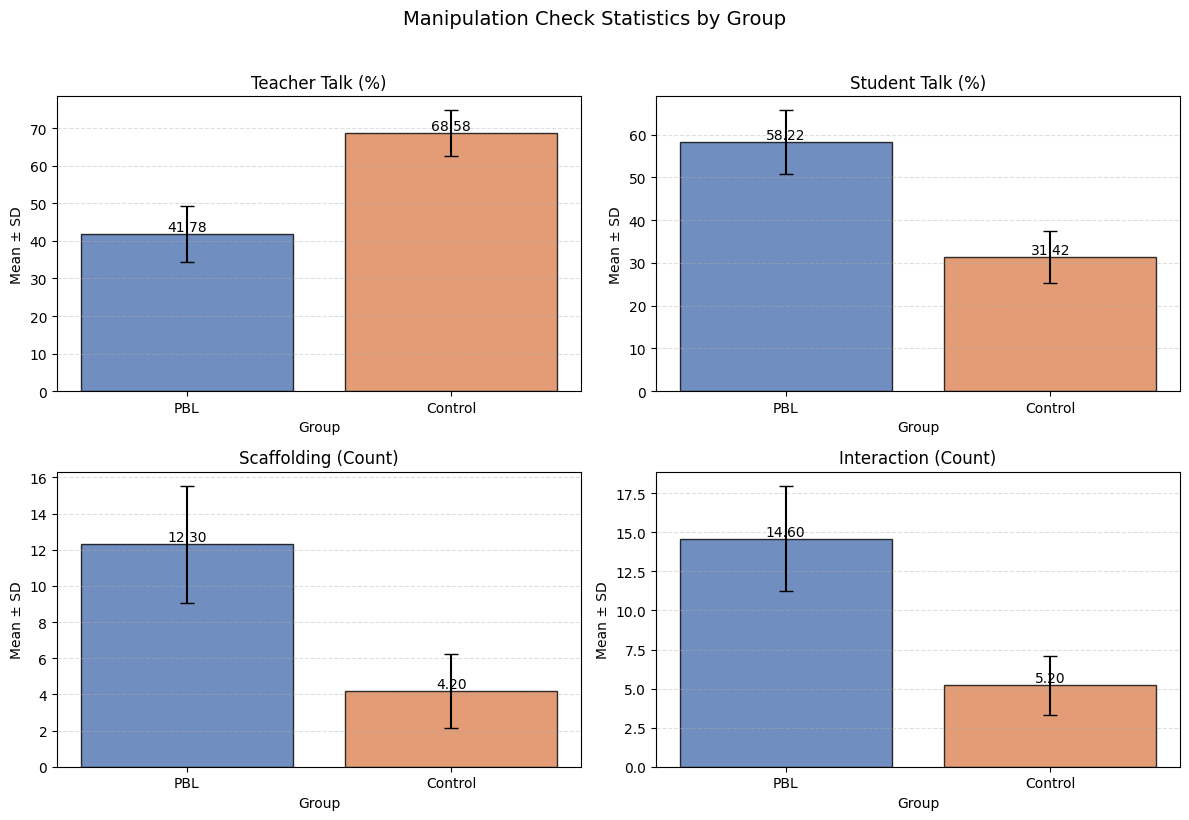

In [4]:
import matplotlib.pyplot as plt

group_order = ['PBL', 'Control']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, analysis_vars):
    means = df.groupby('Group')[col].mean().reindex(group_order)
    stds = df.groupby('Group')[col].std().reindex(group_order)

    bars = ax.bar(
        means.index,
        means.values,
        yerr=stds.values,
        capsize=5,
        color=['#4C72B0', '#DD8452'],
        edgecolor='black',
        alpha=0.8
    )

    ax.set_title(label)
    ax.set_xlabel('Group')
    ax.set_ylabel('Mean ± SD')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for bar, mean in zip(bars, means.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{mean:.2f}',
            ha='center',
            va='bottom'
        )

plt.suptitle('Manipulation Check Statistics by Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

End.